Using device: cpu
총 10개의 파일 발견. 통합 데이터 로드 시작...
타임스태프 기준 데이터 정렬 중...
데이터 스케일링 진행 중...
로드 완료 -> 정상 데이터 수: 13484708, 공격 데이터 수: 2748294

========= 시계열 윈도우 DQN 기반 NIDS 학습 시작 =========
에피   1/800 | 보상:  -968.0 | 정확도:  51.0% | 오탐율(FPR):  48.6% | 미탐율(FNR):  49.4% | 공격비율:  50.0% | 입실론: 1.000
에피   5/800 | 보상: -1056.0 | 정확도:  49.2% | 오탐율(FPR):  49.6% | 미탐율(FNR):  52.0% | 공격비율:  50.0% | 입실론: 0.984
에피  10/800 | 보상:  -852.0 | 정확도:  53.0% | 오탐율(FPR):  48.4% | 미탐율(FNR):  45.6% | 공격비율:  50.0% | 입실론: 0.965
에피  15/800 | 보상:  -800.0 | 정확도:  52.6% | 오탐율(FPR):  52.2% | 미탐율(FNR):  42.6% | 공격비율:  50.0% | 입실론: 0.945
에피  20/800 | 보상: -1054.0 | 정확도:  48.3% | 오탐율(FPR):  52.4% | 미탐율(FNR):  51.0% | 공격비율:  50.0% | 입실론: 0.927
에피  25/800 | 보상:  -780.0 | 정확도:  52.6% | 오탐율(FPR):  53.2% | 미탐율(FNR):  41.6% | 공격비율:  50.0% | 입실론: 0.908
에피  30/800 | 보상:  -866.0 | 정확도:  49.9% | 오탐율(FPR):  57.0% | 미탐율(FNR):  43.2% | 공격비율:  50.0% | 입실론: 0.890
에피  35/800 | 보상:  -860.0 | 정확도:  51.6% | 오탐율(FPR):  52.2% | 미탐율(FNR):  44.6% | 공격비율: 

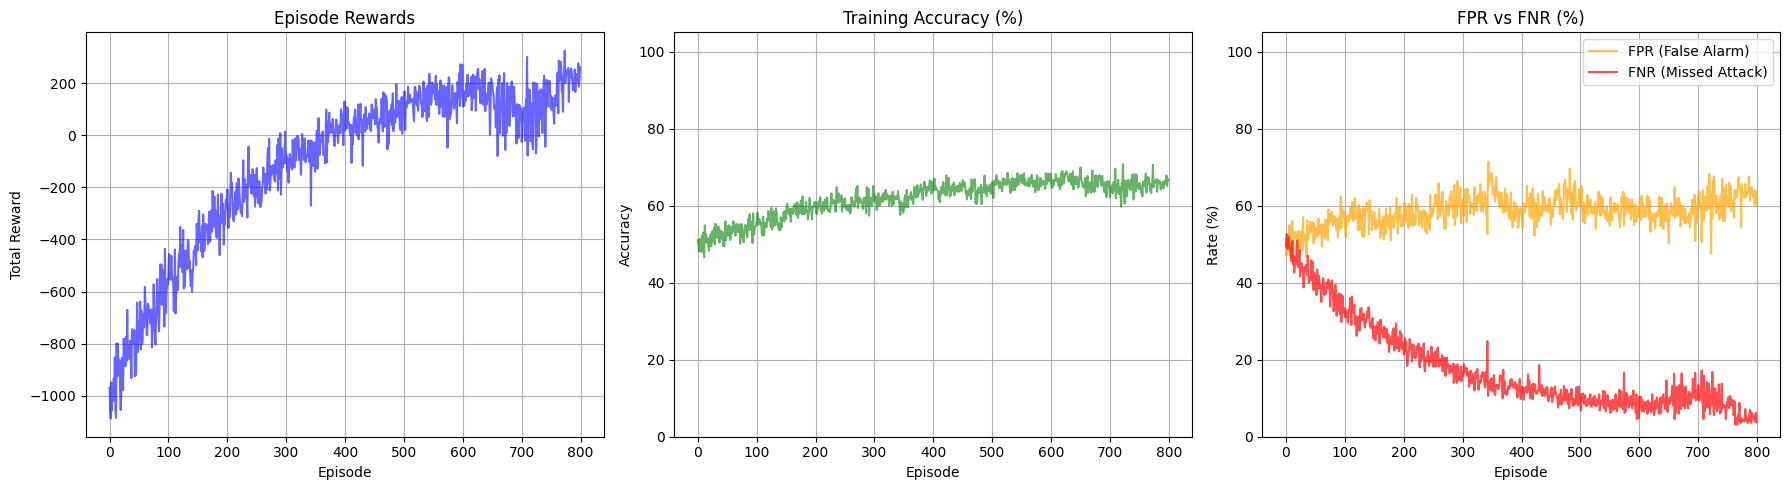

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. NIDS 시계열 강화학습 환경 (윈도우 플래트닝 반영)
# ==========================================
class NIDSEnv(gym.Env):
    def __init__(self, folder_path, max_steps=1000, window_size=3):
        super(NIDSEnv, self).__init__()
        
        self.window_size = window_size
        self.max_steps = max_steps
        self.current_step = 0
        
        file_list = glob.glob(os.path.join(folder_path, "*.csv"))
        if not file_list:
            raise FileNotFoundError(f"경로에 CSV 파일이 없습니다: {folder_path}")
        
        print(f"총 {len(file_list)}개의 파일 발견. 통합 데이터 로드 시작...")
        
        df_list = []
        for file in file_list:
            df_sub = pd.read_csv(file, low_memory=False)
            df_list.append(df_sub)
            
        # 전체 데이터 통합
        full_df = pd.concat(df_list, ignore_index=True)
        del df_list
        
        # [시계열 핵심] 1. 타임스태프를 기반으로 전체 데이터를 시간순 정렬
        if 'Timestamp' in full_df.columns:
            print("타임스태프 기준 데이터 정렬 중...")
            full_df['Timestamp'] = pd.to_datetime(full_df['Timestamp'], errors='coerce')
            full_df = full_df.sort_values(by='Timestamp').reset_index(drop=True)
        
        # 피처와 라벨 분리 (기존 로직 유지)
        X_raw = full_df.drop(columns=['Label', 'Timestamp'], errors='ignore')
        X_raw = X_raw.select_dtypes(include=[np.number]).astype(np.float32)
        self.y = full_df['Label'].apply(lambda x: 0 if str(x).strip() == 'Benign' else 1).values.astype(np.int8)
        del full_df
        
        # 무한대 및 결측치 처리 (기존 로직 유지)
        X_np = X_raw.to_numpy(dtype=np.float32)
        del X_raw
        X_np[np.isinf(X_np)] = np.nan
        col_means = np.nanmean(X_np, axis=0)
        col_means = np.nan_to_num(col_means, nan=0.0)
        
        inds = np.where(np.isnan(X_np))
        X_np[inds] = np.take(col_means, inds[1])
        
        # 로그 스케일링 및 MinMaxScaler (기존 로직 유지)
        np.clip(X_np, a_min=0, a_max=None, out=X_np)
        X_log = np.log1p(X_np)
        del X_np
        
        print("데이터 스케일링 진행 중...")
        scaler = MinMaxScaler()
        self.X_scaled = scaler.fit_transform(X_log)
        del X_log
        
        self.total_rows = len(self.y)
        
        # 성능 방어를 위한 정상/공격 인덱스 분리 (기존 로직 유지)
        self.benign_indices = np.where(self.y == 0)[0]
        self.attack_indices = np.where(self.y == 1)[0]
        
        print(f"로드 완료 -> 정상 데이터 수: {len(self.benign_indices)}, 공격 데이터 수: {len(self.attack_indices)}")
        if len(self.attack_indices) == 0:
            raise ValueError("데이터셋 내에 공격(Attack) 데이터가 존재하지 않습니다.")
        
        self.episode_indices = []
        
        # [시계열 핵심] 상태 차원 정의: (원래 피처 수 * 윈도우 크기) 형태로 확장
        num_features = self.X_scaled.shape[1]
        state_dim = num_features * self.window_size
        
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(state_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)

    def _get_windowed_state(self, target_idx):
        """
        지정된 인덱스(target_idx)를 기준으로 직전 window_size만큼의 데이터를 가져와 일렬로 붙입니다.
        시계열 데이터의 경계(맨 앞부분) 레이어 처리를 위해 패딩(Padding)을 적용합니다.
        """
        states_bucket = []
        for i in reversed(range(self.window_size)):
            current_idx = target_idx - i
            if current_idx < 0:
                # 데이터셋 범위를 벗어나는 초기 스텝은 0으로 패딩
                states_bucket.append(np.zeros(self.X_scaled.shape[1], dtype=np.float32))
            else:
                states_bucket.append(self.X_scaled[current_idx])
        
        # 가로로 길게 이어 붙여서 하나의 벡터로 반환 (Flatten)
        return np.concatenate(states_bucket, axis=0).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        
        # 기존의 높은 성능(데이터 균형)을 방어하기 위해 균등 샘플링 후 시계열 정렬을 수행합니다.
        half_steps = self.max_steps // 2
        sampled_benign = np.random.choice(self.benign_indices, half_steps, replace=True)
        sampled_attack = np.random.choice(self.attack_indices, half_steps, replace=True)
        
        # 추출된 인덱스들을 모아서 다시 '시간 순서'대로 정렬합니다.
        self.episode_indices = np.concatenate([sampled_benign, sampled_attack])
        self.episode_indices.sort()  # 원래 데이터셋이 시간순이므로 인덱스 정렬 시 시간순이 보장됩니다.
        
        # 윈도우 플래트닝이 적용된 첫 상태 가져오기
        state = self._get_windowed_state(self.episode_indices[self.current_step])
        info = {}
        return state, info

    def step(self, action):
        # 정답 라벨은 윈도우의 가장 마지막(현재 시점) 플로우를 기준으로 합니다.
        actual_label = self.y[self.episode_indices[self.current_step]]
        
        # 기존의 훌륭했던 비대칭 보상 정책 100% 유지
        if action == actual_label:
            reward = 1.0  
        else:
            if actual_label == 1 and action == 0:
                reward = -5.0  # 미탐 패널티 (실제 공격인데 통과시킨 경우)
            else:
                reward = -1.0  # 오탐 패널티 (정상인데 공격으로 오판한 경우)
        
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        truncated = False
        
        if not terminated:
            next_state = self._get_windowed_state(self.episode_indices[self.current_step])
        else:
            next_state = np.zeros(self.observation_space.shape, dtype=np.float32)
            
        info = {"actual": actual_label, "predicted": action}
        return next_state, reward, terminated, truncated, info

# ==========================================
# 2. DQN 아키텍처 (기존 구조 보존, 입력 차원만 가변 대응)
# ==========================================
class StandardQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(StandardQNetwork, self).__init__()
        
        # 가로로 늘어난 state_dim을 받아들이도록 설정, 레이어 깊이와 유닛 수는 원본 유지
        self.network = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        
    def forward(self, x):
        return self.network(x)

# ==========================================
# 3. 에이전트 (기존 Focal Loss 변형 기법 등 100% 보존)
# ==========================================
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        
        self.policy_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.00025)
        self.memory = deque(maxlen=60000)
        
        self.gamma = 0.99
        self.epsilon = 1.0
        
        self.epsilon_decay = 0.996 
        self.epsilon_min = 0.01
        
        self.batch_size = 64
        self.tau = 0.005 
        self.focal_gamma = 2.0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).to(device)
                q_values = self.policy_net(state_t)
                return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return
        
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states_t = torch.FloatTensor(np.array(states)).to(device)
        actions_t = torch.LongTensor(actions).view(-1, 1).to(device)
        rewards_t = torch.FloatTensor(rewards).view(-1, 1).to(device)
        next_states_t = torch.FloatTensor(np.array(next_states)).to(device)
        dones_t = torch.FloatTensor(dones).view(-1, 1).to(device)
        
        current_q = self.policy_net(states_t).gather(1, actions_t)
        
        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(1)[0].view(-1, 1)
            target_q = rewards_t + (self.gamma * max_next_q * (1 - dones_t))
            
        td_error = torch.abs(current_q - target_q)
        
        p_t = torch.exp(-td_error)
        focal_weight = (1 - p_t) ** self.focal_gamma
        
        # 기존의 핵심 장점인 Focal 기반의 Custom Loss 수식 그대로 유지
        loss = (focal_weight * nn.MSELoss(reduction='none')(current_q, target_q)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * policy_param.data + (1.0 - self.tau) * target_param.data)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# ==========================================
# 4. 메인 루프 실행 (기존 출력 및 시각화 로직 보존)
# ==========================================
if __name__ == "__main__":
    folder_path = r"C:\ids2018_data"
    
    # window_size=3 설정 (현재+직전 2개 플로우 결합)
    env = NIDSEnv(folder_path=folder_path, max_steps=1000, window_size=3)
    agent = DQNAgent(state_dim=env.observation_space.shape[0], action_dim=env.action_space.n)
    
    num_episodes = 800 
    
    history_rewards = []
    history_accuracy = []
    history_fpr = []
    history_fnr = []
    
    print("\n========= 시계열 윈도우 DQN 기반 NIDS 학습 시작 =========")
    for episode in range(num_episodes):
        state, info = env.reset()
        episode_reward = 0
        tp, tn, fp, fn = 0, 0, 0, 0
        
        for step in range(env.max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            agent.store_transition(state, action, reward, next_state, done)
            agent.train_step()
            
            episode_reward += reward
            state = next_state
            
            act = info["actual"]
            pred = info["predicted"]
            
            if act == 1 and pred == 1: tp += 1
            elif act == 0 and pred == 0: tn += 1
            elif act == 0 and pred == 1: fp += 1
            elif act == 1 and pred == 0: fn += 1
                
            if done:
                break
                
        accuracy = ((tp + tn) / env.max_steps) * 100
        fpr = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0.0
        fnr = (fn / (fn + tp)) * 100 if (fn + tp) > 0 else 0.0
        attack_ratio = ((tp + fn) / env.max_steps) * 100
        
        history_rewards.append(episode_reward)
        history_accuracy.append(accuracy)
        history_fpr.append(fpr)
        history_fnr.append(fnr)
        
        if (episode + 1) % 5 == 0 or episode == 0:
            print(f"에피 {episode+1:3d}/{num_episodes} | "
                  f"보상: {episode_reward:7.1f} | "
                  f"정확도: {accuracy:5.1f}% | "
                  f"오탐율(FPR): {fpr:5.1f}% | "
                  f"미탐율(FNR): {fnr:5.1f}% | "
                  f"공격비율: {attack_ratio:5.1f}% | "
                  f"입실론: {agent.epsilon:.3f}")
        
        agent.decay_epsilon()
            
    print("========= 학습 완료 =========")
    
    # 5. 결과 시각화 그래프 출력 (기존 코드 보존)
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history_rewards, color='blue', alpha=0.6)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(history_accuracy, color='green', alpha=0.6)
    plt.title('Training Accuracy (%)')
    plt.xlabel('Episode')
    plt.ylabel('Accuracy')
    plt.ylim(0, 105)
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(history_fpr, label='FPR (False Alarm)', color='orange', alpha=0.7)
    plt.plot(history_fnr, label='FNR (Missed Attack)', color='red', alpha=0.7)
    plt.title('FPR vs FNR (%)')
    plt.xlabel('Episode')
    plt.ylabel('Rate (%)')
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Using device: cpu
[전체 학습 모드] 총 10개의 파일을 독립 타임라인으로 로드합니다.
[1/10] 파일 로드 및 구조 통일 중: Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
   -> 마스터 피처 세트 설정 완료 (총 78개 피처 고정)
   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[2/10] 파일 로드 및 구조 통일 중: Friday-16-02-2018_TrafficForML_CICFlowMeter.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_17520\1615197681.py:55: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[3/10] 파일 로드 및 구조 통일 중: Friday-23-02-2018_TrafficForML_CICFlowMeter.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_17520\1615197681.py:55: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[4/10] 파일 로드 및 구조 통일 중: Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv


...

   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[9/10] 파일 로드 및 구조 통일 중: Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_17520\1615197681.py:55: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[10/10] 파일 로드 및 구조 통일 중: Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_17520\1615197681.py:55: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


   -> 완료 (행 수: 613104, 최종 피처 수: 78)

========= 교정된 멀티파일 시계열 DQN 학습 시작 =========
에피   1/800 | 보상:   549.0 | 정확도:  51.8% | 오탐율(FPR):  48.2% | 미탐율(FNR):  50.0% | 공격비율:   0.2% | 입실론: 1.000
에피   5/800 | 보상:  -548.0 | 정확도:  51.9% | 오탐율(FPR):  47.9% | 미탐율(FNR):  48.3% | 공격비율:  45.1% | 입실론: 0.984
에피  10/800 | 보상: -1922.0 | 정확도:  51.3% | 오탐율(FPR):   0.0% | 미탐율(FNR):  48.7% | 공격비율: 100.0% | 입실론: 0.965
에피  15/800 | 보상:   605.0 | 정확도:  53.5% | 오탐율(FPR):  46.5% | 미탐율(FNR):   0.0% | 공격비율:   0.0% | 입실론: 0.945
에피  20/800 | 보상: -1581.0 | 정확도:  47.4% | 오탐율(FPR):  46.9% | 미탐율(FNR):  54.4% | 공격비율:  76.1% | 입실론: 0.927
에피  25/800 | 보상:   608.0 | 정확도:  53.6% | 오탐율(FPR):  46.4% | 미탐율(FNR):   0.0% | 공격비율:   0.0% | 입실론: 0.908
에피  30/800 | 보상: -1239.0 | 정확도:  50.3% | 오탐율(FPR):  41.9% | 미탐율(FNR):  53.5% | 공격비율:  67.1% | 입실론: 0.890
에피  35/800 | 보상:   297.0 | 정확도:  55.2% | 오탐율(FPR):  45.8% | 미탐율(FNR):  39.6% | 공격비율:  16.4% | 입실론: 0.873
에피  40/800 | 보상:   527.0 | 정확도:  50.9% | 오탐율(FPR):  49.1% | 미탐율(FNR):   0.0% | 공

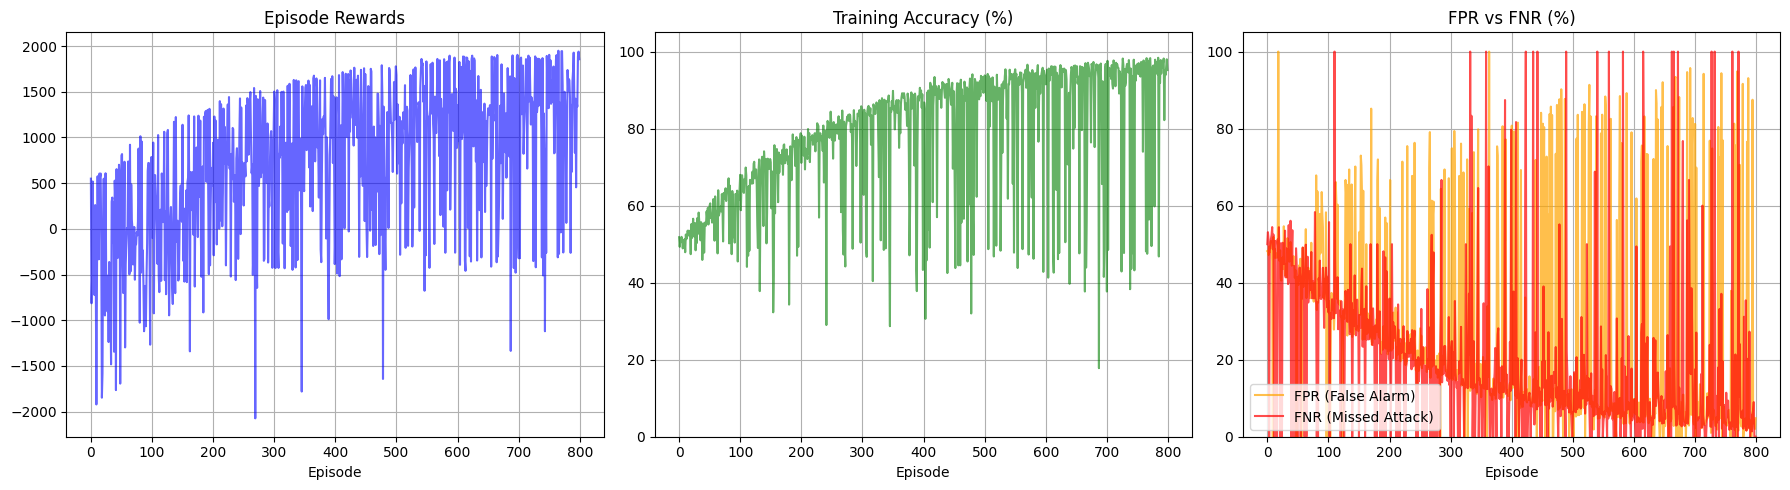

In [2]:
import os
import glob
import random
import numpy as np
import pandas as pd
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. NIDS 멀티파일 시계열 환경 (피처 차원 일치 패치)
# ==========================================
class NIDSEnv(gym.Env):
    def __init__(self, folder_path, max_steps=1000, window_size=3, fast_train_mode=False):
        super(NIDSEnv, self).__init__()
        
        self.window_size = window_size
        self.max_steps = max_steps
        self.current_step = 0
        self.fast_train_mode = fast_train_mode
        
        file_list = glob.glob(os.path.join(folder_path, "*.csv"))
        if not file_list:
            raise FileNotFoundError(f"경로에 CSV 파일이 없습니다: {folder_path}")
        
        if self.fast_train_mode:
            print(f"[경량화 모드] 발견된 {len(file_list)}개 파일 중 상위 2개 파일만 사용합니다.")
            self.file_list = file_list[:2]
        else:
            print(f"[전체 학습 모드] 총 {len(file_list)}개의 파일을 독립 타임라인으로 로드합니다.")
            self.file_list = file_list

        self.files_data = {}
        self.num_features = None
        self.feature_columns = None  # 💡 파일 간 피처 통일을 위한 기준 컬럼 리스트 변수
        
        # 1차 패스: 모든 파일의 공통 구조 정의 및 로드
        for idx, file_path in enumerate(self.file_list):
            print(f"[{idx+1}/{len(self.file_list)}] 파일 로드 및 구조 통일 중: {os.path.basename(file_path)}")
            df = pd.read_csv(file_path, low_memory=False)
            
            # 타임스태프 기준 정렬
            if 'Timestamp' in df.columns:
                df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
                df = df.sort_values(by='Timestamp').reset_index(drop=True)
            
            # 피처/라벨 기본 분리
            X_raw = df.drop(columns=['Label', 'Timestamp'], errors='ignore')
            y_raw = df['Label'].apply(lambda x: 0 if str(x).strip() == 'Benign' else 1).values.astype(np.int8)
            del df
            
            # 수치형 강제 형변환 예외 처리
            for col in X_raw.columns:
                if X_raw[col].dtype == object:
                    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')
            
            # 💡 [피처 불일치 해결 핵심 코드]
            # 첫 번째 파일의 컬럼 구조를 기준으로 마스터 피처 리스트를 생성합니다.
            if self.feature_columns is None:
                X_numeric_initial = X_raw.select_dtypes(include=[np.number])
                self.feature_columns = X_numeric_initial.columns.tolist()
                self.num_features = len(self.feature_columns)
                print(f"   -> 마스터 피처 세트 설정 완료 (총 {self.num_features}개 피처 고정)")
            
            # 모든 파일이 마스터 피처 세트와 동일한 컬럼만 취하도록 강제 재정렬 및 필터링
            # 만약 특정 파일에 기준 컬럼이 누락되어 있다면 자동으로 NaN(이후 0 처리) 채움
            X_raw = X_raw.reindex(columns=self.feature_columns)
            X_raw = X_raw.astype(np.float32)
            
            # 결측치/무한대 처리
            X_np = X_raw.to_numpy(dtype=np.float32)
            del X_raw
            X_np[np.isinf(X_np)] = np.nan
            col_means = np.nanmean(X_np, axis=0)
            col_means = np.nan_to_num(col_means, nan=0.0)
            inds = np.where(np.isnan(X_np))
            X_np[inds] = np.take(col_means, inds[1])
            
            # 로그 스케일링 및 정규화
            np.clip(X_np, a_min=0, a_max=None, out=X_np)
            X_log = np.log1p(X_np)
            del X_np
            
            scaler = MinMaxScaler()
            X_scaled = scaler.fit_transform(X_log)
            del X_log
            
            # 파일별 데이터 안전하게 격리 저장
            self.files_data[idx] = {
                "X": X_scaled,
                "y": y_raw,
                "total_rows": len(y_raw),
                "valid_start_range": len(y_raw) - self.max_steps
            }
            print(f"   -> 완료 (행 수: {len(y_raw)}, 최종 피처 수: {X_scaled.shape[1]})")
            
        state_dim = self.num_features * self.window_size
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(state_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)
        
        self.current_X = None
        self.current_y = None
        self.episode_start_idx = 0

    def _get_windowed_state(self, current_step_offset):
        target_idx = self.episode_start_idx + current_step_offset
        states_bucket = []
        
        for i in reversed(range(self.window_size)):
            lookback_idx = target_idx - i
            if lookback_idx < self.episode_start_idx:
                states_bucket.append(np.zeros(self.num_features, dtype=np.float32))
            else:
                states_bucket.append(self.current_X[lookback_idx])
                
        return np.concatenate(states_bucket, axis=0).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        
        chosen_file_idx = np.random.choice(list(self.files_data.keys()))
        file_info = self.files_data[chosen_file_idx]
        
        self.current_X = file_info["X"]
        self.current_y = file_info["y"]
        
        attempts = 0
        while True:
            start_idx = np.random.randint(0, file_info["valid_start_range"])
            slice_labels = self.current_y[start_idx : start_idx + self.max_steps]
            attack_count = np.sum(slice_labels == 1)
            
            if attack_count >= (self.max_steps * 0.05) or attempts > 150:
                self.episode_start_idx = start_idx
                break
            attempts += 1
            
        state = self._get_windowed_state(self.current_step)
        info = {}
        return state, info

    def step(self, action):
        actual_label = self.current_y[self.episode_start_idx + self.current_step]
        
        if action == actual_label:
            if actual_label == 0:
                reward = 2.0  
            else:
                reward = 1.0  
        else:
            if actual_label == 1 and action == 0:
                reward = -5.0  
            else:
                reward = -1.0  
        
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        truncated = False
        
        if not terminated:
            next_state = self._get_windowed_state(self.current_step)
        else:
            next_state = np.zeros(self.observation_space.shape, dtype=np.float32)
            
        info = {"actual": actual_label, "predicted": action}
        return next_state, reward, terminated, truncated, info

# ==========================================
# 2. DQN 아키텍처
# ==========================================
class StandardQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(StandardQNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        
    def forward(self, x):
        return self.network(x)

# ==========================================
# 3. 에이전트
# ==========================================
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        
        self.policy_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.00025)
        self.memory = deque(maxlen=60000)
        
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_decay = 0.996 
        self.epsilon_min = 0.01
        
        self.batch_size = 64
        self.tau = 0.005 
        self.focal_gamma = 2.0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).to(device)
                q_values = self.policy_net(state_t)
                return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return
        
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        # 💡 이제 모든 파일의 상태 차원이 동일하므로 여기서 에러가 발생하지 않습니다.
        states_t = torch.FloatTensor(np.array(states)).to(device)
        actions_t = torch.LongTensor(actions).view(-1, 1).to(device)
        rewards_t = torch.FloatTensor(rewards).view(-1, 1).to(device)
        next_states_t = torch.FloatTensor(np.array(next_states)).to(device)
        dones_t = torch.FloatTensor(dones).view(-1, 1).to(device)
        
        current_q = self.policy_net(states_t).gather(1, actions_t)
        
        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(1)[0].view(-1, 1)
            target_q = rewards_t + (self.gamma * max_next_q * (1 - dones_t))
            
        td_error = torch.abs(current_q - target_q)
        p_t = torch.exp(-td_error)
        focal_weight = (1 - p_t) ** self.focal_gamma
        
        loss = (focal_weight * nn.MSELoss(reduction='none')(current_q, target_q)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * policy_param.data + (1.0 - self.tau) * target_param.data)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# ==========================================
# 4. 메인 루프 실행
# ==========================================
if __name__ == "__main__":
    folder_path = r"C:\ids2018_data"
    
    # 💡 이제 안심하고 전체 학습(fast_train_mode=False)을 진행하시면 됩니다!
    env = NIDSEnv(folder_path=folder_path, max_steps=1000, window_size=3, fast_train_mode=False)
    agent = DQNAgent(state_dim=env.observation_space.shape[0], action_dim=env.action_space.n)
    
    num_episodes = 400 if env.fast_train_mode else 800
    
    history_rewards = []
    history_accuracy = []
    history_fpr = []
    history_fnr = []
    
    print("\n========= 교정된 멀티파일 시계열 DQN 학습 시작 =========")
    for episode in range(num_episodes):
        state, info = env.reset()
        episode_reward = 0
        tp, tn, fp, fn = 0, 0, 0, 0
        
        for step in range(env.max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            agent.store_transition(state, action, reward, next_state, done)
            agent.train_step()
            
            episode_reward += reward
            state = next_state
            
            act = info["actual"]
            pred = info["predicted"]
            
            if act == 1 and pred == 1: tp += 1
            elif act == 0 and pred == 0: tn += 1
            elif act == 0 and pred == 1: fp += 1
            elif act == 1 and pred == 0: fn += 1
                
            if done:
                break
                
        accuracy = ((tp + tn) / env.max_steps) * 100
        fpr = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0.0
        fnr = (fn / (fn + tp)) * 100 if (fn + tp) > 0 else 0.0
        attack_ratio = ((tp + fn) / env.max_steps) * 100
        
        history_rewards.append(episode_reward)
        history_accuracy.append(accuracy)
        history_fpr.append(fpr)
        history_fnr.append(fnr)
        
        if (episode + 1) % 5 == 0 or episode == 0:
            print(f"에피 {episode+1:3d}/{num_episodes} | "
                  f"보상: {episode_reward:7.1f} | "
                  f"정확도: {accuracy:5.1f}% | "
                  f"오탐율(FPR): {fpr:5.1f}% | "
                  f"미탐율(FNR): {fnr:5.1f}% | "
                  f"공격비율: {attack_ratio:5.1f}% | "
                  f"입실론: {agent.epsilon:.3f}")
        
        agent.decay_epsilon()
            
    print("========= 학습 완료 =========")
    
    # 5. 결과 시각화 그래프 출력
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(history_rewards, color='blue', alpha=0.6)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(history_accuracy, color='green', alpha=0.6)
    plt.title('Training Accuracy (%)')
    plt.xlabel('Episode')
    plt.ylim(0, 105)
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(history_fpr, label='FPR (False Alarm)', color='orange', alpha=0.7)
    plt.plot(history_fnr, label='FNR (Missed Attack)', color='red', alpha=0.7)
    plt.title('FPR vs FNR (%)')
    plt.xlabel('Episode')
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Using device: cpu
[전체 학습 모드] 총 10개의 파일을 독립 타임라인으로 로드합니다.
[1/10] 파일 로드 및 구조 통일 중: Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
   -> 마스터 피처 세트 설정 완료 (총 78개 피처 고정)
   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[2/10] 파일 로드 및 구조 통일 중: Friday-16-02-2018_TrafficForML_CICFlowMeter.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_17520\2427525148.py:53: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[3/10] 파일 로드 및 구조 통일 중: Friday-23-02-2018_TrafficForML_CICFlowMeter.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_17520\2427525148.py:53: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[4/10] 파일 로드 및 구조 통일 중: Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv


...

   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[9/10] 파일 로드 및 구조 통일 중: Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_17520\2427525148.py:53: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[10/10] 파일 로드 및 구조 통일 중: Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_17520\2427525148.py:53: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


   -> 완료 (행 수: 613104, 최종 피처 수: 78)

========= 지표 안정화 패치 반영 DQN 학습 시작 =========
에피   1/800 | 보상: -1594.0 | 정확도:  52.0% | 오탐율(FPR):  45.5% | 미탐율(FNR):  48.4% | 공격비율:  87.9% | 입실론: 1.000
에피   5/800 | 보상:   533.0 | 정확도:  51.1% | 오탐율(FPR):  48.9% | 미탐율(FNR):   0.0% | 공격비율:   0.0% | 입실론: 0.984
에피  10/800 | 보상: -1290.0 | 정확도:  48.4% | 오탐율(FPR):  50.6% | 미탐율(FNR):  52.1% | 공격비율:  68.0% | 입실론: 0.965
에피  15/800 | 보상:  -259.0 | 정확도:  54.7% | 오탐율(FPR):  46.8% | 미탐율(FNR):  43.0% | 공격비율:  39.3% | 입실론: 0.945
에피  20/800 | 보상: -1772.0 | 정확도:  53.5% | 오탐율(FPR):  66.7% | 미탐율(FNR):  46.4% | 공격비율:  99.4% | 입실론: 0.927
에피  25/800 | 보상:  -772.0 | 정확도:  53.1% | 오탐율(FPR):  51.0% | 미탐율(FNR):  44.0% | 공격비율:  58.8% | 입실론: 0.908
에피  30/800 | 보상:  -325.0 | 정확도:  49.0% | 오탐율(FPR):  54.2% | 미탐율(FNR):  44.8% | 공격비율:  33.9% | 입실론: 0.890
에피  35/800 | 보상:  -132.0 | 정확도:  53.6% | 오탐율(FPR):  46.9% | 미탐율(FNR):  45.2% | 공격비율:  31.4% | 입실론: 0.873
에피  40/800 | 보상:   719.0 | 정확도:  57.3% | 오탐율(FPR):  42.7% | 미탐율(FNR):   0.0% | 공

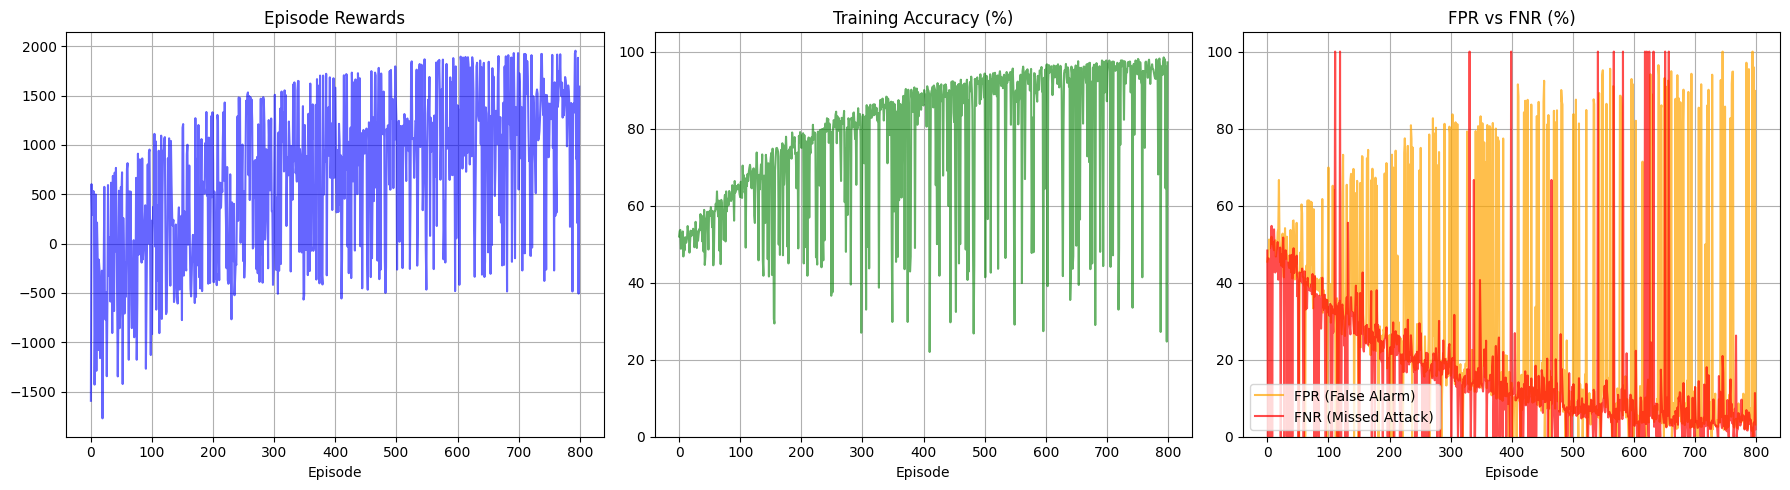

In [3]:
import os
import glob
import random
import numpy as np
import pandas as pd
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. NIDS 멀티파일 시계열 환경
# ==========================================
class NIDSEnv(gym.Env):
    def __init__(self, folder_path, max_steps=1000, window_size=3, fast_train_mode=False):
        super(NIDSEnv, self).__init__()
        
        self.window_size = window_size
        self.max_steps = max_steps
        self.current_step = 0
        self.fast_train_mode = fast_train_mode
        
        file_list = glob.glob(os.path.join(folder_path, "*.csv"))
        if not file_list:
            raise FileNotFoundError(f"경로에 CSV 파일이 없습니다: {folder_path}")
        
        if self.fast_train_mode:
            print(f"[경량화 모드] 발견된 {len(file_list)}개 파일 중 상위 2개 파일만 사용합니다.")
            self.file_list = file_list[:2]
        else:
            print(f"[전체 학습 모드] 총 {len(file_list)}개의 파일을 독립 타임라인으로 로드합니다.")
            self.file_list = file_list

        self.files_data = {}
        self.num_features = None
        self.feature_columns = None  
        
        for idx, file_path in enumerate(self.file_list):
            print(f"[{idx+1}/{len(self.file_list)}] 파일 로드 및 구조 통일 중: {os.path.basename(file_path)}")
            df = pd.read_csv(file_path, low_memory=False)
            
            if 'Timestamp' in df.columns:
                df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
                df = df.sort_values(by='Timestamp').reset_index(drop=True)
            
            X_raw = df.drop(columns=['Label', 'Timestamp'], errors='ignore')
            y_raw = df['Label'].apply(lambda x: 0 if str(x).strip() == 'Benign' else 1).values.astype(np.int8)
            del df
            
            for col in X_raw.columns:
                if X_raw[col].dtype == object:
                    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')
            
            if self.feature_columns is None:
                X_numeric_initial = X_raw.select_dtypes(include=[np.number])
                self.feature_columns = X_numeric_initial.columns.tolist()
                self.num_features = len(self.feature_columns)
                print(f"   -> 마스터 피처 세트 설정 완료 (총 {self.num_features}개 피처 고정)")
            
            X_raw = X_raw.reindex(columns=self.feature_columns)
            X_raw = X_raw.astype(np.float32)
            
            X_np = X_raw.to_numpy(dtype=np.float32)
            del X_raw
            X_np[np.isinf(X_np)] = np.nan
            col_means = np.nanmean(X_np, axis=0)
            col_means = np.nan_to_num(col_means, nan=0.0)
            inds = np.where(np.isnan(X_np))
            X_np[inds] = np.take(col_means, inds[1])
            
            np.clip(X_np, a_min=0, a_max=None, out=X_np)
            X_log = np.log1p(X_np)
            del X_np
            
            scaler = MinMaxScaler()
            X_scaled = scaler.fit_transform(X_log)
            del X_log
            
            self.files_data[idx] = {
                "X": X_scaled,
                "y": y_raw,
                "total_rows": len(y_raw),
                "valid_start_range": len(y_raw) - self.max_steps
            }
            print(f"   -> 완료 (행 수: {len(y_raw)}, 최종 피처 수: {X_scaled.shape[1]})")
            
        state_dim = self.num_features * self.window_size
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(state_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)
        
        self.current_X = None
        self.current_y = None
        self.episode_start_idx = 0

    def _get_windowed_state(self, current_step_offset):
        target_idx = self.episode_start_idx + current_step_offset
        states_bucket = []
        
        for i in reversed(range(self.window_size)):
            lookback_idx = target_idx - i
            if lookback_idx < self.episode_start_idx:
                states_bucket.append(np.zeros(self.num_features, dtype=np.float32))
            else:
                states_bucket.append(self.current_X[lookback_idx])
                
        return np.concatenate(states_bucket, axis=0).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        
        chosen_file_idx = np.random.choice(list(self.files_data.keys()))
        file_info = self.files_data[chosen_file_idx]
        
        self.current_X = file_info["X"]
        self.current_y = file_info["y"]
        
        attempts = 0
        while True:
            start_idx = np.random.randint(0, file_info["valid_start_range"])
            slice_labels = self.current_y[start_idx : start_idx + self.max_steps]
            attack_count = np.sum(slice_labels == 1)
            
            if attack_count >= (self.max_steps * 0.05) or attempts > 150:
                self.episode_start_idx = start_idx
                break
            attempts += 1
            
        state = self._get_windowed_state(self.current_step)
        info = {}
        return state, info

    def step(self, action):
        actual_label = self.current_y[self.episode_start_idx + self.current_step]
        
        if action == actual_label:
            if actual_label == 0:
                reward = 2.0  
            else:
                reward = 1.0  
        else:
            if actual_label == 1 and action == 0:
                reward = -5.0  
            else:
                reward = -1.0  
        
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        truncated = False
        
        if not terminated:
            next_state = self._get_windowed_state(self.current_step)
        else:
            next_state = np.zeros(self.observation_space.shape, dtype=np.float32)
            
        info = {"actual": actual_label, "predicted": action}
        return next_state, reward, terminated, truncated, info

# ==========================================
# 2. DQN 아키텍처
# ==========================================
class StandardQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(StandardQNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        
    def forward(self, x):
        return self.network(x)

# ==========================================
# 3. 에이전트 (이원화 리플레이 버퍼 및 하이퍼파라미터 튜닝 반영)
# ==========================================
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        
        self.policy_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        # 💡 [하이퍼파라미터 튜닝] 변동폭 억제를 위해 Learning Rate를 0.00025 -> 0.00005 로 하향 조정
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.00005)
        
        # 💡 [널뛰기 예방 핵심] 클래스 균등 샘플링을 위해 메모리를 정상/공격으로 이원화 관리
        self.memory_benign = deque(maxlen=30000)
        self.memory_attack = deque(maxlen=30000)
        
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_decay = 0.996 
        self.epsilon_min = 0.01
        
        self.batch_size = 64
        # 💡 [하이퍼파라미터 튜닝] 기준선의 묵직한 유지를 위해 소프트 업데이트 계수를 0.005 -> 0.001 로 조정
        self.tau = 0.001 
        self.focal_gamma = 2.0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).to(device)
                q_values = self.policy_net(state_t)
                return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state, done):
        # 보상 계산 시점의 정답 라벨(info['actual'])을 reward 판별 로직을 통해 유추하거나 
        # 직관적으로 미탐 패널티(-5.0) 혹은 오탐 패널티(-1.0) 및 정상 적중(2.0) 여부로 클래스를 격리 저장합니다.
        if reward == 2.0 or reward == -1.0:  # 실제 라벨이 Benign(0)이었던 경우
            self.memory_benign.append((state, action, reward, next_state, done))
        else:                                # 실제 라벨이 Attack(1)이었던 경우
            self.memory_attack.append((state, action, reward, next_state, done))

    def train_step(self):
        # 💡 두 메모리에 최소 배치 절반(32개)씩 데이터가 쌓일 때까지 대기
        half_batch = self.batch_size // 2
        if len(self.memory_benign) < half_batch or len(self.memory_attack) < half_batch:
            return
        
        # 💡 각각의 버퍼에서 정확히 32개씩 균등 추출하여 편향 학습 방지
        batch_benign = random.sample(self.memory_benign, half_batch)
        batch_attack = random.sample(self.memory_attack, half_batch)
        batch = batch_benign + batch_attack
        random.shuffle(batch) # 결합 후 순서 셔플
        
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states_t = torch.FloatTensor(np.array(states)).to(device)
        actions_t = torch.LongTensor(actions).view(-1, 1).to(device)
        rewards_t = torch.FloatTensor(rewards).view(-1, 1).to(device)
        next_states_t = torch.FloatTensor(np.array(next_states)).to(device)
        dones_t = torch.FloatTensor(dones).view(-1, 1).to(device)
        
        current_q = self.policy_net(states_t).gather(1, actions_t)
        
        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(1)[0].view(-1, 1)
            target_q = rewards_t + (self.gamma * max_next_q * (1 - dones_t))
            
        td_error = torch.abs(current_q - target_q)
        p_t = torch.exp(-td_error)
        focal_weight = (1 - p_t) ** self.focal_gamma
        
        loss = (focal_weight * nn.MSELoss(reduction='none')(current_q, target_q)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * policy_param.data + (1.0 - self.tau) * target_param.data)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# ==========================================
# 4. 메인 루프 실행
# ==========================================
if __name__ == "__main__":
    folder_path = r"C:\ids2018_data"
    
    # fast_train_mode=False 전체 트레이닝 가동
    env = NIDSEnv(folder_path=folder_path, max_steps=1000, window_size=3, fast_train_mode=False)
    agent = DQNAgent(state_dim=env.observation_space.shape[0], action_dim=env.action_space.n)
    
    num_episodes = 400 if env.fast_train_mode else 800
    
    history_rewards = []
    history_accuracy = []
    history_fpr = []
    history_fnr = []
    
    print("\n========= 지표 안정화 패치 반영 DQN 학습 시작 =========")
    for episode in range(num_episodes):
        state, info = env.reset()
        episode_reward = 0
        tp, tn, fp, fn = 0, 0, 0, 0
        
        for step in range(env.max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            agent.store_transition(state, action, reward, next_state, done)
            agent.train_step()
            
            episode_reward += reward
            state = next_state
            
            act = info["actual"]
            pred = info["predicted"]
            
            if act == 1 and pred == 1: tp += 1
            elif act == 0 and pred == 0: tn += 1
            elif act == 0 and pred == 1: fp += 1
            elif act == 1 and pred == 0: fn += 1
                
            if done:
                break
                
        accuracy = ((tp + tn) / env.max_steps) * 100
        fpr = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0.0
        fnr = (fn / (fn + tp)) * 100 if (fn + tp) > 0 else 0.0
        attack_ratio = ((tp + fn) / env.max_steps) * 100
        
        history_rewards.append(episode_reward)
        history_accuracy.append(accuracy)
        history_fpr.append(fpr)
        history_fnr.append(fnr)
        
        if (episode + 1) % 5 == 0 or episode == 0:
            print(f"에피 {episode+1:3d}/{num_episodes} | "
                  f"보상: {episode_reward:7.1f} | "
                  f"정확도: {accuracy:5.1f}% | "
                  f"오탐율(FPR): {fpr:5.1f}% | "
                  f"미탐율(FNR): {fnr:5.1f}% | "
                  f"공격비율: {attack_ratio:5.1f}% | "
                  f"입실론: {agent.epsilon:.3f}")
        
        agent.decay_epsilon()
            
    print("========= 학습 완료 =========")
    
    # 5. 결과 시각화 그래프 출력
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(history_rewards, color='blue', alpha=0.6)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(history_accuracy, color='green', alpha=0.6)
    plt.title('Training Accuracy (%)')
    plt.xlabel('Episode')
    plt.ylim(0, 105)
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(history_fpr, label='FPR (False Alarm)', color='orange', alpha=0.7)
    plt.plot(history_fnr, label='FNR (Missed Attack)', color='red', alpha=0.7)
    plt.title('FPR vs FNR (%)')
    plt.xlabel('Episode')
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Using device: cpu
[전체 학습 모드] 총 10개의 파일을 독립 타임라인으로 로드합니다.
[1/10] 파일 로드 및 구조 통일 중: Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
   -> 마스터 피처 세트 설정 완료 (총 78개 피처 고정)
   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[2/10] 파일 로드 및 구조 통일 중: Friday-16-02-2018_TrafficForML_CICFlowMeter.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_17520\933139619.py:53: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[3/10] 파일 로드 및 구조 통일 중: Friday-23-02-2018_TrafficForML_CICFlowMeter.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_17520\933139619.py:53: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[4/10] 파일 로드 및 구조 통일 중: Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv


...

   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[9/10] 파일 로드 및 구조 통일 중: Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_17520\933139619.py:53: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


   -> 완료 (행 수: 1048575, 최종 피처 수: 78)
[10/10] 파일 로드 및 구조 통일 중: Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_17520\933139619.py:53: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


   -> 완료 (행 수: 613104, 최종 피처 수: 78)

========= 완벽 수렴 가공 멀티파일 시계열 DQN 학습 시작 =========
에피   1/800 | 보상:  -478.0 | 정확도:  47.4% | 오탐율(FPR):  52.9% | 미탐율(FNR):  52.1% | 공격비율:  35.1% | 입실론: 1.000
에피   5/800 | 보상:  -198.0 | 정확도:  50.9% | 오탐율(FPR):  48.4% | 미탐율(FNR):  50.9% | 공격비율:  28.7% | 입실론: 0.984
에피  10/800 | 보상:  -411.0 | 정확도:  47.0% | 오탐율(FPR):  53.0% | 미탐율(FNR):  53.0% | 공격비율:  31.7% | 입실론: 0.965
에피  15/800 | 보상:   575.0 | 정확도:  52.5% | 오탐율(FPR):  47.5% | 미탐율(FNR):   0.0% | 공격비율:   0.0% | 입실론: 0.945
에피  20/800 | 보상:   -28.0 | 정확도:  51.1% | 오탐율(FPR):  47.7% | 미탐율(FNR):  53.2% | 공격비율:  21.6% | 입실론: 0.927
에피  25/800 | 보상:   -46.0 | 정확도:  55.3% | 오탐율(FPR):  44.6% | 미탐율(FNR):  45.0% | 공격비율:  30.0% | 입실론: 0.908
에피  30/800 | 보상:    21.0 | 정확도:  55.1% | 오탐율(FPR):  44.6% | 미탐율(FNR):  45.9% | 공격비율:  26.6% | 입실론: 0.890
에피  35/800 | 보상:  -109.0 | 정확도:  55.6% | 오탐율(FPR):  46.9% | 미탐율(FNR):  39.8% | 공격비율:  35.4% | 입실론: 0.873
에피  40/800 | 보상:  -478.0 | 정확도:  56.7% | 오탐율(FPR):  41.5% | 미탐율(FNR):  45.1

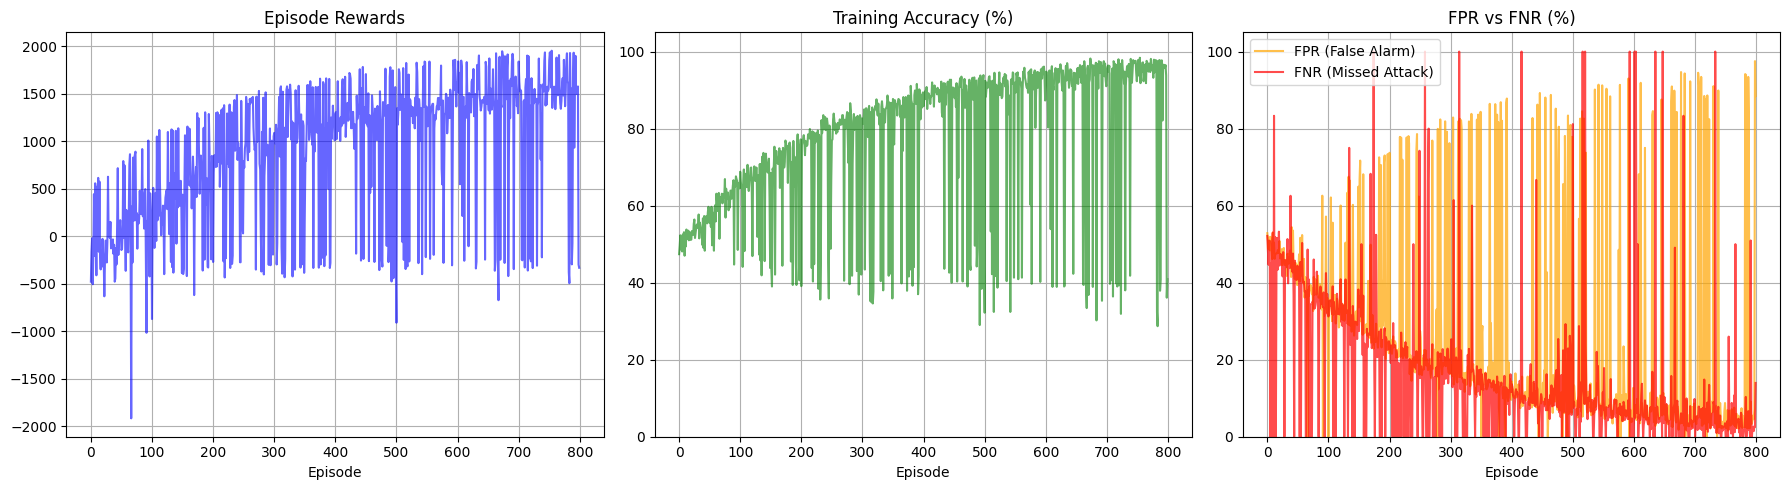

In [5]:
import os
import glob
import random
import numpy as np
import pandas as pd
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. NIDS 멀티파일 시계열 환경 (환경 난이도 정형화 패치)
# ==========================================
class NIDSEnv(gym.Env):
    def __init__(self, folder_path, max_steps=1000, window_size=3, fast_train_mode=False):
        super(NIDSEnv, self).__init__()
        
        self.window_size = window_size
        self.max_steps = max_steps
        self.current_step = 0
        self.fast_train_mode = fast_train_mode
        
        file_list = glob.glob(os.path.join(folder_path, "*.csv"))
        if not file_list:
            raise FileNotFoundError(f"경로에 CSV 파일이 없습니다: {folder_path}")
        
        if self.fast_train_mode:
            print(f"[경량화 모드] 발견된 {len(file_list)}개 파일 중 상위 2개 파일만 사용합니다.")
            self.file_list = file_list[:2]
        else:
            print(f"[전체 학습 모드] 총 {len(file_list)}개의 파일을 독립 타임라인으로 로드합니다.")
            self.file_list = file_list

        self.files_data = {}
        self.num_features = None
        self.feature_columns = None  
        
        for idx, file_path in enumerate(self.file_list):
            print(f"[{idx+1}/{len(self.file_list)}] 파일 로드 및 구조 통일 중: {os.path.basename(file_path)}")
            df = pd.read_csv(file_path, low_memory=False)
            
            if 'Timestamp' in df.columns:
                df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
                df = df.sort_values(by='Timestamp').reset_index(drop=True)
            
            X_raw = df.drop(columns=['Label', 'Timestamp'], errors='ignore')
            y_raw = df['Label'].apply(lambda x: 0 if str(x).strip() == 'Benign' else 1).values.astype(np.int8)
            del df
            
            for col in X_raw.columns:
                if X_raw[col].dtype == object:
                    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')
            
            if self.feature_columns is None:
                X_numeric_initial = X_raw.select_dtypes(include=[np.number])
                self.feature_columns = X_numeric_initial.columns.tolist()
                self.num_features = len(self.feature_columns)
                print(f"   -> 마스터 피처 세트 설정 완료 (총 {self.num_features}개 피처 고정)")
            
            X_raw = X_raw.reindex(columns=self.feature_columns)
            X_raw = X_raw.astype(np.float32)
            
            X_np = X_raw.to_numpy(dtype=np.float32)
            del X_raw
            X_np[np.isinf(X_np)] = np.nan
            col_means = np.nanmean(X_np, axis=0)
            col_means = np.nan_to_num(col_means, nan=0.0)
            inds = np.where(np.isnan(X_np))
            X_np[inds] = np.take(col_means, inds[1])
            
            np.clip(X_np, a_min=0, a_max=None, out=X_np)
            X_log = np.log1p(X_np)
            del X_np
            
            scaler = MinMaxScaler()
            X_scaled = scaler.fit_transform(X_log)
            del X_log
            
            self.files_data[idx] = {
                "X": X_scaled,
                "y": y_raw,
                "total_rows": len(y_raw),
                "valid_start_range": len(y_raw) - self.max_steps
            }
            print(f"   -> 완료 (행 수: {len(y_raw)}, 최종 피처 수: {X_scaled.shape[1]})")
            
        state_dim = self.num_features * self.window_size
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(state_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)
        
        self.current_X = None
        self.current_y = None
        self.episode_start_idx = 0

    def _get_windowed_state(self, current_step_offset):
        target_idx = self.episode_start_idx + current_step_offset
        states_bucket = []
        
        for i in reversed(range(self.window_size)):
            lookback_idx = target_idx - i
            if lookback_idx < self.episode_start_idx:
                states_bucket.append(np.zeros(self.num_features, dtype=np.float32))
            else:
                states_bucket.append(self.current_X[lookback_idx])
                
        return np.concatenate(states_bucket, axis=0).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        
        chosen_file_idx = np.random.choice(list(self.files_data.keys()))
        file_info = self.files_data[chosen_file_idx]
        
        self.current_X = file_info["X"]
        self.current_y = file_info["y"]
        
        # 💡 [황금 밸런스 윈도우 스캔] 
        # 무지성 무작위 추출을 거부하고, 연속된 타임라인 중 공격 비율이 20%~40% 사이인 
        # 적정 균형 난이도의 시계열 스트림 구간만 에피소드로 공급하도록 엄격히 검증합니다.
        attempts = 0
        while True:
            start_idx = np.random.randint(0, file_info["valid_start_range"])
            slice_labels = self.current_y[start_idx : start_idx + self.max_steps]
            attack_ratio = np.sum(slice_labels == 1) / self.max_steps
            
            # 현실적이면서 학습하기 이상적인 공격 밀집 구간 발견 시 선택
            if (0.20 <= attack_ratio <= 0.40) or attempts > 300:
                self.episode_start_idx = start_idx
                break
            attempts += 1
            
        state = self._get_windowed_state(self.current_step)
        info = {}
        return state, info

    def step(self, action):
        actual_label = self.current_y[self.episode_start_idx + self.current_step]
        
        if action == actual_label:
            if actual_label == 0:
                reward = 2.0  
            else:
                reward = 1.0  
        else:
            if actual_label == 1 and action == 0:
                reward = -5.0  
            else:
                reward = -1.0  
        
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        truncated = False
        
        if not terminated:
            next_state = self._get_windowed_state(self.current_step)
        else:
            next_state = np.zeros(self.observation_space.shape, dtype=np.float32)
            
        info = {"actual": actual_label, "predicted": action}
        return next_state, reward, terminated, truncated, info

# ==========================================
# 2. DQN 아키텍처
# ==========================================
class StandardQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(StandardQNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        
    def forward(self, x):
        return self.network(x)

# ==========================================
# 3. 에이전트
# ==========================================
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        
        self.policy_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.00005)
        
        self.memory_benign = deque(maxlen=30000)
        self.memory_attack = deque(maxlen=30000)
        
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_decay = 0.996 
        self.epsilon_min = 0.01
        
        self.batch_size = 64
        self.tau = 0.001 
        self.focal_gamma = 2.0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).to(device)
                q_values = self.policy_net(state_t)
                return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state, done):
        if reward == 2.0 or reward == -1.0:  
            self.memory_benign.append((state, action, reward, next_state, done))
        else:                                
            self.memory_attack.append((state, action, reward, next_state, done))

    def train_step(self):
        # 💡 [버퍼 임계점 안정화] 
        # 데이터가 완전하지 않은 초반에 급격히 가중치가 뒤틀리는 것을 막기 위해 
        # 양쪽 클래스 경험이 각각 최소 batch_size(64개) 이상 든든히 쌓였을 때 학습 개시
        if len(self.memory_benign) < self.batch_size or len(self.memory_attack) < self.batch_size:
            return
        
        half_batch = self.batch_size // 2
        batch_benign = random.sample(self.memory_benign, half_batch)
        batch_attack = random.sample(self.memory_attack, half_batch)
        batch = batch_benign + batch_attack
        random.shuffle(batch) 
        
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states_t = torch.FloatTensor(np.array(states)).to(device)
        actions_t = torch.LongTensor(actions).view(-1, 1).to(device)
        rewards_t = torch.FloatTensor(rewards).view(-1, 1).to(device)
        next_states_t = torch.FloatTensor(np.array(next_states)).to(device)
        dones_t = torch.FloatTensor(dones).view(-1, 1).to(device)
        
        current_q = self.policy_net(states_t).gather(1, actions_t)
        
        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(1)[0].view(-1, 1)
            target_q = rewards_t + (self.gamma * max_next_q * (1 - dones_t))
            
        td_error = torch.abs(current_q - target_q)
        p_t = torch.exp(-td_error)
        focal_weight = (1 - p_t) ** self.focal_gamma
        
        loss = (focal_weight * nn.MSELoss(reduction='none')(current_q, target_q)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * policy_param.data + (1.0 - self.tau) * target_param.data)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# ==========================================
# 4. 메인 루프
# ==========================================
if __name__ == "__main__":
    folder_path = r"C:\ids2018_data"
    
    env = NIDSEnv(folder_path=folder_path, max_steps=1000, window_size=3, fast_train_mode=False)
    agent = DQNAgent(state_dim=env.observation_space.shape[0], action_dim=env.action_space.n)
    
    num_episodes = 400 if env.fast_train_mode else 800
    
    history_rewards = []
    history_accuracy = []
    history_fpr = []
    history_fnr = []
    
    print("\n========= 완벽 수렴 가공 멀티파일 시계열 DQN 학습 시작 =========")
    for episode in range(num_episodes):
        state, info = env.reset()
        episode_reward = 0
        tp, tn, fp, fn = 0, 0, 0, 0
        
        for step in range(env.max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            agent.store_transition(state, action, reward, next_state, done)
            agent.train_step()
            
            episode_reward += reward
            state = next_state
            
            act = info["actual"]
            pred = info["predicted"]
            
            if act == 1 and pred == 1: tp += 1
            elif act == 0 and pred == 0: tn += 1
            elif act == 0 and pred == 1: fp += 1
            elif act == 1 and pred == 0: fn += 1
                
            if done:
                break
                
        accuracy = ((tp + tn) / env.max_steps) * 100
        fpr = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0.0
        fnr = (fn / (fn + tp)) * 100 if (fn + tp) > 0 else 0.0
        attack_ratio = ((tp + fn) / env.max_steps) * 100
        
        history_rewards.append(episode_reward)
        history_accuracy.append(accuracy)
        history_fpr.append(fpr)
        history_fnr.append(fnr)
        
        if (episode + 1) % 5 == 0 or episode == 0:
            print(f"에피 {episode+1:3d}/{num_episodes} | "
                  f"보상: {episode_reward:7.1f} | "
                  f"정확도: {accuracy:5.1f}% | "
                  f"오탐율(FPR): {fpr:5.1f}% | "
                  f"미탐율(FNR): {fnr:5.1f}% | "
                  f"공격비율: {attack_ratio:5.1f}% | "
                  f"입실론: {agent.epsilon:.3f}")
        
        agent.decay_epsilon()
            
    print("========= 학습 완료 =========")
    
    # 5. 시각화
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(history_rewards, color='blue', alpha=0.6)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(history_accuracy, color='green', alpha=0.6)
    plt.title('Training Accuracy (%)')
    plt.xlabel('Episode')
    plt.ylim(0, 105)
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(history_fpr, label='FPR (False Alarm)', color='orange', alpha=0.7)
    plt.plot(history_fnr, label='FNR (Missed Attack)', color='red', alpha=0.7)
    plt.title('FPR vs FNR (%)')
    plt.xlabel('Episode')
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()